I have opted for a conservative trading style and have attempted to limit losses by taking lesser risks. The stop loss value chosen for the same is 0.02 or 2%. This limits potential profits but also reduces risks but it is more suitable for less volatile markets. For volume RSI I have used a 14 days look back period because it is more dependable and we have used close values for average true value and MACD calculation because they represent the final sentiment of the market at the end of a day and are not affected by overnight news. For the MACD I have used the standard 12 days and 26 day period. This is because together these provide a great balance between sensitivity levels for different durations of price movements and are good for both short term and long term trends.

No crossover occurs.
Backtest Results:
Total Profit: 61915.20
Annualized Return: 0.00
Sharpe Ratio: 0.09
Max Drawdown: 0.73
Winning Trades: 9961.00
Losing Trades: 9708.00


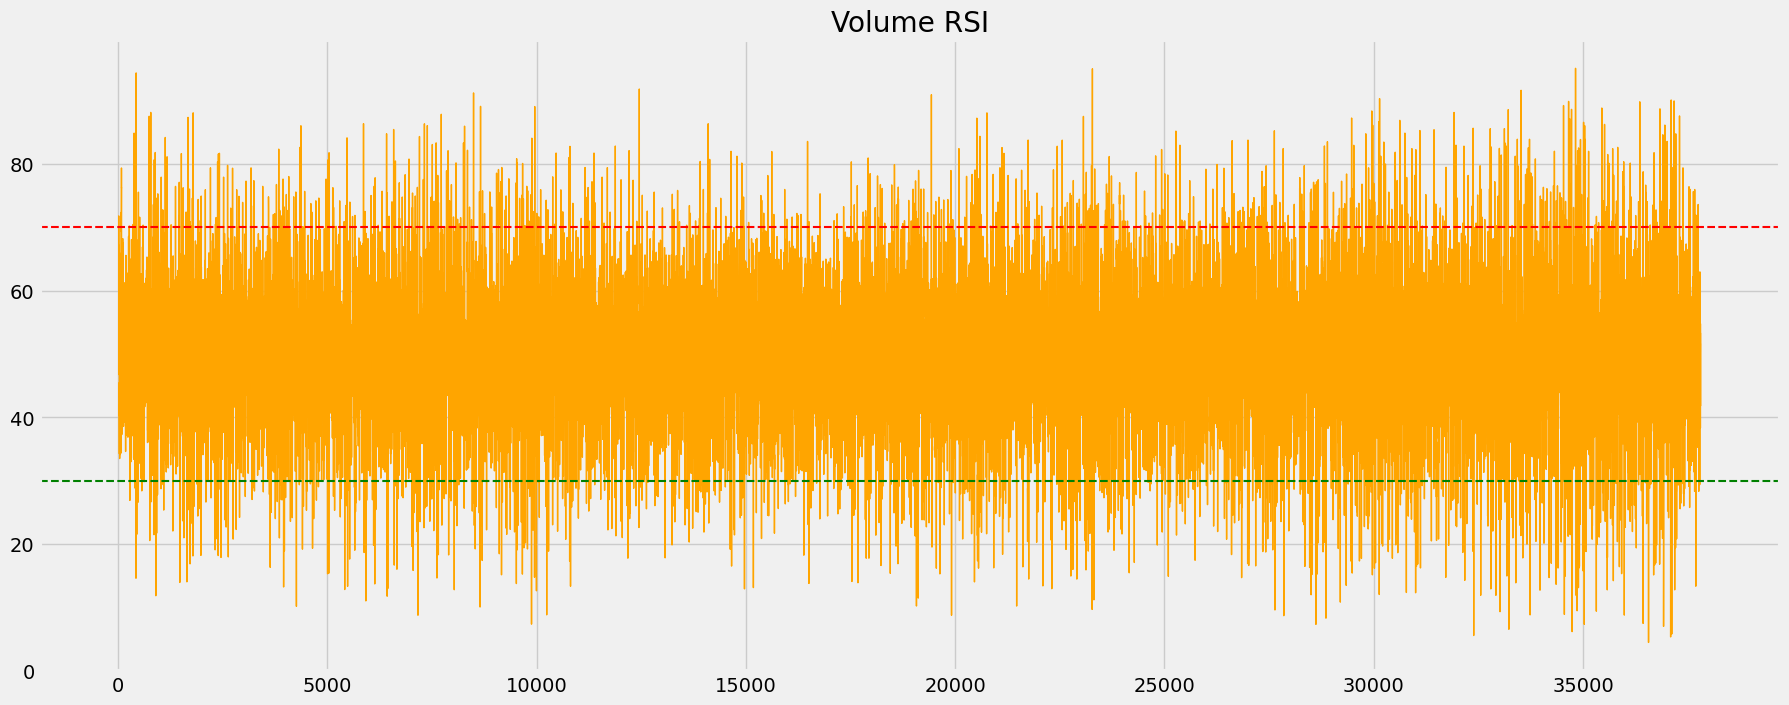

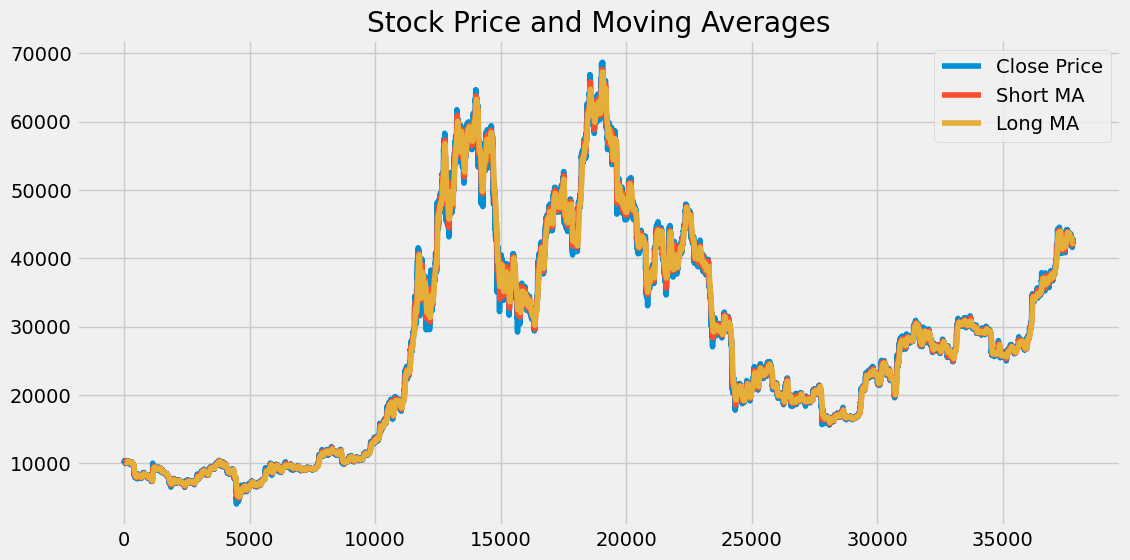

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def calculate_macd(data):
    #Calculate the 12-period EMA
    data['EMA12'] = data['close'].ewm(span=12, adjust=False).mean()

    # Calculate the 26-period EMA
    data['EMA26'] = data['close'].ewm(span=26, adjust=False).mean()

    # Calculate MACD (the difference between 12-period EMA and 26-period EMA)
    data['MACD'] = data['EMA12'] - data['EMA26']

    # Calculate the 9-period EMA of MACD (Signal Line)
    data['Signal_Line'] = data['MACD'].ewm(span=9, adjust=False).mean()
    # Check for MACD and Signal Line crossovers in the last two rows
    last_row = data.iloc[-1]
    second_last_row = data.iloc[-2]

    #define output based on various situations of crossing over
    if second_last_row['MACD'] > second_last_row['Signal_Line'] and last_row['MACD'] < last_row['Signal_Line']:
        print('The sentiment  is bearish because the MACD line is lesser than the signal line.')
    elif second_last_row['MACD'] < second_last_row['Signal_Line'] and last_row['MACD'] > last_row['Signal_Line']:
        print('The sentiment is bullish because the MACD line is greater than the signal line.')
    else:
        print('No crossover occurs.')
    #print(data['MACD'], data['Signal_Line'])
def calculate_moving_average(data, window):
    return data.rolling(window=window).mean()

def calculate_rsi(data):
    #Volume RSI
    change = data["volume"].diff()
    change.dropna(inplace=True)

    # Create two copies of the Closing price Series
    change_up = change.copy()
    change_down = change.copy()

    # Keep only positive values for change up and negative ones for change down
    change_up[change_up<0] = 0
    change_down[change_down>0] = 0

    # Verify that we did not make any mistakes
    change.equals(change_up+change_down)

    # Calculate the rolling average of average up and average down
    avg_up = change_up.rolling(14).mean()
    avg_down = change_down.rolling(14).mean().abs()
    rsi = 100 * avg_up / (avg_up + avg_down)
    rsi.head(20)

    #Set the theme of our chart
    plt.style.use('fivethirtyeight')

    # Make our resulting figure much bigger
    plt.rcParams['figure.figsize'] = (20, 20)
    ax1 = plt.subplot2grid((10,1), (5,0), rowspan = 4, colspan = 1)

    ax1.set_title('Volume RSI')
    ax1.plot(rsi, color='orange', linewidth=1)
    # Add two horizontal lines, signalling the buy and sell ranges.
    # Oversold
    ax1.axhline(30, linestyle='--', linewidth=1.5, color='green')
    # Overbought
    ax1.axhline(70, linestyle='--', linewidth=1.5, color='red')


def generate_trading_signals(data, short_window, long_window, rsi_period, overbought_rsi, oversold_rsi):
    data['Short_MA'] = calculate_moving_average(data['close'], short_window)
    data['Long_MA'] = calculate_moving_average(data['close'], long_window)
    data['RSI'] = calculate_rsi(data)

    data['Signal'] = 0.0
    data.loc[data['Short_MA'] > data['Long_MA'], 'Signal'] = 1.0  # Buy Signal
    data.loc[data['Short_MA'] < data['Long_MA'], 'Signal'] = -1.0  # Sell Signal

    # Incorporate RSI signals
    data.loc[data['RSI'] >= overbought_rsi, 'Signal'] = -1.0  # Sell Signal (Overbought)
    data.loc[data['RSI'] <= oversold_rsi, 'Signal'] = 1.0  # Buy Signal (Oversold)
    calculate_macd(data)

    return data

def backtest_strategy(data, initial_capital=100000):
    positions = data['Signal'].shift(1)
    portfolio_value = [initial_capital]

    for i in range(1, len(data)):
        if positions[i] == 1:  # Buy
            portfolio_value.append(portfolio_value[i-1] * (1 + (data['close'][i] - data['close'][i-1]) / data['close'][i-1]))
        elif positions[i] == -1:  # Sell
            portfolio_value.append(portfolio_value[i-1] * (1 - (data['close'][i] - data['close'][i-1]) / data['close'][i-1]))
        else:
            portfolio_value.append(portfolio_value[i-1])

    portfolio_value = np.array(portfolio_value)
    returns = (portfolio_value[1:] / portfolio_value[:-1]) - 1
    

    # Calculate performance metrics
    total_profit = portfolio_value[-1] - initial_capital
    annualized_return = (portfolio_value[-1] / initial_capital)**(252 / len(data)) - 1
    sharpe_ratio = np.mean(returns) / np.std(returns) * np.sqrt(252)
    max_drawdown = (np.maximum.accumulate(portfolio_value) - portfolio_value).max() / np.maximum.accumulate(portfolio_value).max()
    winning_trades = len(data[(data['Signal'].shift(1) == 1) & (data['close'] > data['close'].shift(1))])
    losing_trades = len(data[(data['Signal'].shift(1) == 1) & (data['close'] < data['close'].shift(1))])

    return {
        'Total Profit': total_profit,
        'Annualized Return': annualized_return,
        'Sharpe Ratio': sharpe_ratio,
        'Max Drawdown': max_drawdown,
        'Winning Trades': winning_trades,
        'Losing Trades': losing_trades,
    }

# Load data from CSV file
data = pd.read_csv('CSV resource.csv')

# Define strategy parameters
short_window = 20
long_window = 50
rsi_period = 14
overbought_rsi = 70
oversold_rsi = 30

# Generate trading signals
data = generate_trading_signals(data, short_window, long_window, rsi_period, overbought_rsi, oversold_rsi)

# Backtest the strategy
backtest_results = backtest_strategy(data)

# Print backtest results
print("Backtest Results:")
for metric, value in backtest_results.items():
    print(f"{metric}: {value:.2f}")

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(data['close'], label='Close Price')
plt.plot(data['Short_MA'], label='Short MA')
plt.plot(data['Long_MA'], label='Long MA')
plt.legend()
plt.title('Stock Price and Moving Averages')
plt.show()

